# Bedingungen gegenüberstellen

Zwei Messreihen, und in beiden variieren **zwei** Faktoren, nicht einer:

| | Hautreiz | Akustik | Reizkopf |
|---|---|---|---|
| **13.08.** Fuß | Fuß | gedämpft | — |
| **13.08.** Oberarm | Oberarm | gedämpft | — |
| **13.08.** Kontrolle | — | gedämpft | — |
| **13.08.** ungedämpft | — | **ungedämpft** | — |
| **09.09.** Kontrolle | — | gedämpft | — |
| **09.09.** Oberschenkel | Oberschenkel | gedämpft | Linse |
| **09.09.** Wade | Wade | gedämpft | Linse |
| **09.09.** Wade | Wade | gedämpft | normaler Kopf (2×) |

*gedämpft = Noise-Cancelling-Kopfhörer aktiv.*

**Der naheliegende Fehlschluss:** „ungedämpft" gegen „Kontrolle" zu lesen als
Reiz gegen Kontrolle. In beiden wird **kein Hautreiz** gesetzt — sie
unterscheiden sich allein in der Dämpfung. Der Vergleich misst also, was die
Kopfhörer *entfernen*, nicht eine Störung in den Messdaten. Alle
Hautreiz-Aufnahmen liefen bereits mit Kopfhörern.

Vier Fragen, in dieser Reihenfolge:

1. Was nimmt das Noise-Cancelling weg?
2. Kommt der Reiz vom Fuß später an als vom Oberarm?
3. Ist der fokussierende Applikator (Linse) dem normalen Reizkopf überlegen?
4. Unterscheidet sich Oberschenkel von Wade?

Bei jeder Frage gilt dieselbe Reihenfolge: erst **die Kontrolle**, dann
**das Maß**, dann **die Rauschgrenze des Maßes** — erst dann die Aussage.

## 1 · Vorbereitung

In [1]:
%load_ext autoreload
%autoreload 2

import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = pathlib.Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from offline import (load_session, OfflineFilter, replay, use_app_style,
                     plot_compare, plot_cluster_test, plot_selection,
                     peak_latency, crosscorr_shift, bootstrap_shift,
                     bootstrap_difference, cluster_permutation_test,
                     split_half_reliability, single_trial_consistency,
                     evoked_rms, mean_amplitude, matched_subsample)

use_app_style(dark=True)
pd.set_option("display.width", 200)

## 2 · Dateien, Beschriftung, Verarbeitung

**Beide Faktoren gehören in jede Beschriftung.** Sobald „kein Hautreiz" in
zwei Zeilen steht, sieht man in der Legende sofort, dass sich nur die
Dämpfung unterscheidet.

**Alle Bedingungen bekommen exakt dieselbe Behandlung** — gleiche
Filterkette, gleiches Fenster, gleiche Auswahlregel. Wer an einer Bedingung
anders dreht als an einer anderen, misst die Verarbeitung statt der Daten.

`drop_first=10` ist das Messprotokoll (Einlaufphase). Das zusätzliche
`last=` gleicht die Epochenzahl an: die Kontrolle vom 13.08. hat 68 Trigger
gegen 40 bei der ungedämpften Bedingung, und ein Mittelwert aus doppelt so
vielen Epochen ist allein deshalb glatter.

In [2]:
AUG13 = {
    "Fuß · gedämpft":          "recordings/ERP_20260813_131731_stimulationFuss.csv",
    "Oberarm · gedämpft":      "recordings/ERP_20260813_125428_stimulationOberarm.csv",
    "kein Hautreiz · gedämpft":   "recordings/ERP_20260813_122821_keinReiz.csv",
    "kein Hautreiz · ungedämpft": "recordings/ERP_20260813_122235_nurAkustisch.csv",
}
SEP9 = {
    "kein Hautreiz · gedämpft":  "recordings/ERP_20260909_163744.csv",
    "Oberschenkel · Linse":      "recordings/ERP_20260909_164514.csv",
    "Wade · Linse":              "recordings/ERP_20260909_165220.csv",
    "Wade · normaler Kopf (1)":  "recordings/ERP_20260909_170018.csv",
    "Wade · normaler Kopf (2)":  "recordings/ERP_20260909_171102.csv",
}
FARBEN = {
    "Fuß · gedämpft": "#4a9eff", "Oberarm · gedämpft": "#ffa726",
    "kein Hautreiz · gedämpft": "#7d8794",
    "kein Hautreiz · ungedämpft": "#f97b8b",
    "Oberschenkel · Linse": "#4a9eff", "Wade · Linse": "#3ddc84",
    "Wade · normaler Kopf (1)": "#f97b8b", "Wade · normaler Kopf (2)": "#8b7cf6",
}

PARAM      = dict(pre_ms=200, post_ms=2000, drop_first=10, mad_k=3.5,
                  threshold=None, with_tfr=False)
PARAM_AUG13 = dict(PARAM, last=29)     # Epochenzahl angleichen
ROI = ["Fz", "Cz", "Pz"]               # dieselbe ROI wie die TFR der App

In [3]:
class RoiView:
    """Sicht auf das ROI-Mittel — damit Abbildung und Statistik dieselbe
    Kurve sehen."""
    def __init__(self, r, roi=ROI):
        self._r, self._i = r, [r.ch(c) for c in roi]
        self.time_axis, self.label = r.time_axis, r.label
        self.n_accepted, self.ch_labels = r.n_accepted, ["ROI"]
    def ch(self, name): return 0
    def trace(self, _=None):        return self._r.erp_mean[:, self._i].mean(1)
    def epoch_traces(self, _=None): return self._r.epochs[:, :, self._i].mean(2)


def lade(dateien, param=PARAM):
    out = {}
    for name, p in dateien.items():
        s = load_session(p)
        eeg = OfflineFilter(fs=s.fs).highpass(1.0).notch(50.0)(s.raw)
        out[name] = RoiView(replay(eeg, s.trigger_idx, fs=s.fs,
                                   ch_labels=s.ch_labels, label=name, **param))
    return out


def farben(keys):
    return {k: FARBEN[k] for k in keys if k in FARBEN}


a13 = lade(AUG13, PARAM_AUG13)
s09 = lade(SEP9)
t = a13["Fuß · gedämpft"].time_axis

pd.DataFrame([{"Reihe": r, "Bedingung": k, "n": v.n_accepted}
              for r, d in [("13.08.", a13), ("09.09.", s09)]
              for k, v in d.items()])

,Reihe,Bedingung,n
0,13.08.,Fuß · gedämpft,28
1,13.08.,Oberarm · gedämpft,26
2,13.08.,kein Hautreiz · gedämpft,29
3,13.08.,kein Hautreiz · ungedämpft,28
4,09.09.,kein Hautreiz · gedämpft,49
5,09.09.,Oberschenkel · Linse,45
6,09.09.,Wade · Linse,25
7,09.09.,Wade · normaler Kopf (1),29
8,09.09.,Wade · normaler Kopf (2),21


## 3 · Frage 1 — Was nimmt das Noise-Cancelling weg?

Beide Bedingungen ohne Hautreiz, nur die Dämpfung unterscheidet sich. Der
Cluster-Permutationstest fasst benachbarte Zeitpunkte mit |t| > 2 zu
Clustern zusammen und prüft deren Masse gegen eine Nullverteilung aus
vertauschten Etiketten — nötig, weil man bei 550 Zeitpunkten ohne Korrektur
immer irgendwo etwas findet.

 von_ms  bis_ms   masse  t_max     p
  8.379  52.459 -34.568 -3.764 0.021
256.831 280.874  18.512  3.077 0.151
585.428 585.428   2.064  2.064 0.944
601.457 601.457   2.011  2.011 0.958


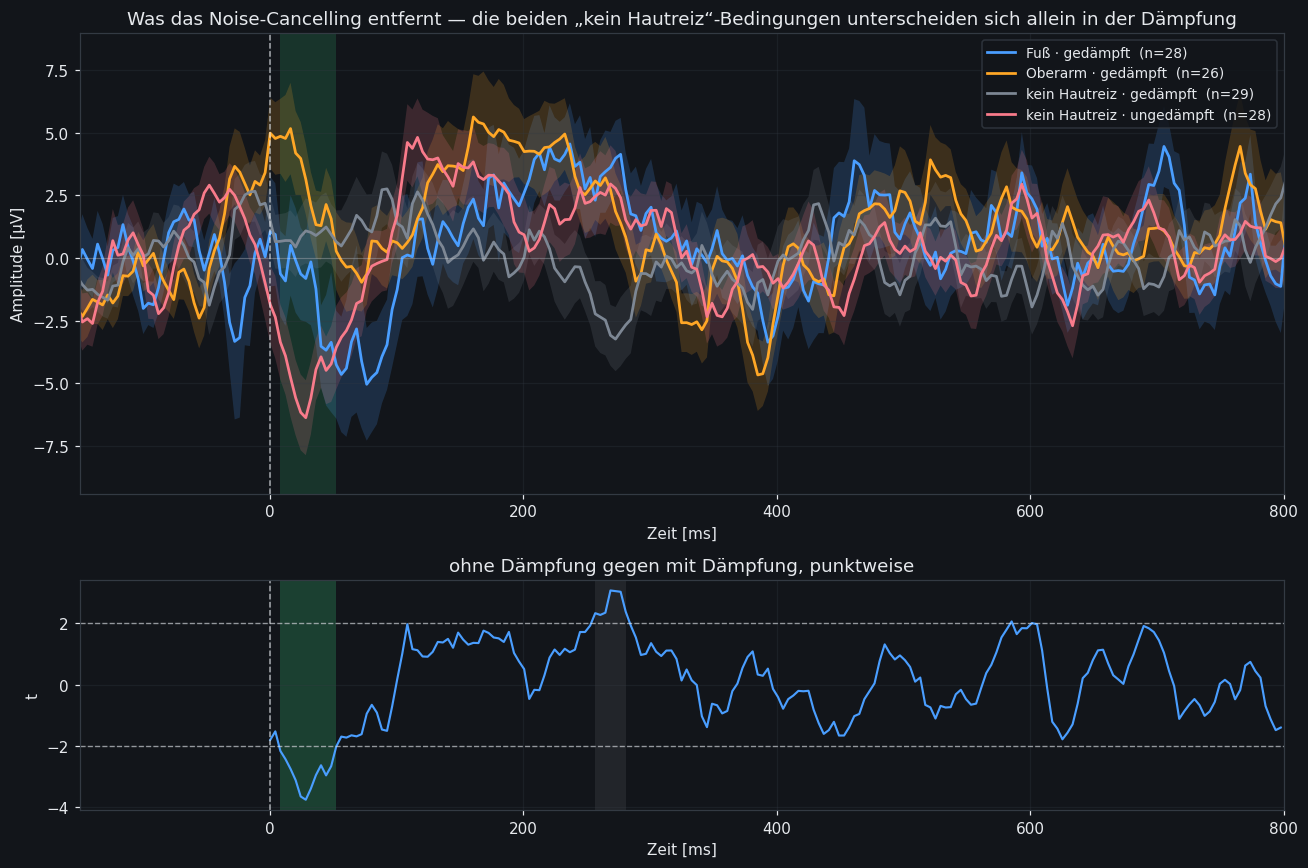

In [4]:
A, B = "kein Hautreiz · ungedämpft", "kein Hautreiz · gedämpft"
test_nc = cluster_permutation_test(a13[A].epoch_traces(),
                                   a13[B].epoch_traces(),
                                   t, window=(0, 800), n_perm=3000)
print(test_nc["cluster"].round(3).to_string(index=False))

fig, ax = plt.subplots(2, 1, figsize=(12, 8),
                       gridspec_kw={"height_ratios": [2, 1]})
plot_compare(a13, "ROI", ax=ax[0], xlim=(-150, 800), clusters=test_nc,
             colors=farben(a13),
             title="Was das Noise-Cancelling entfernt — die beiden "
                   "\u201ekein Hautreiz\u201c-Bedingungen unterscheiden sich "
                   "allein in der Dämpfung")
plot_cluster_test(test_nc, ax=ax[1])
ax[1].set_xlim(-150, 800)
ax[1].set_title("ohne Dämpfung gegen mit Dämpfung, punktweise")
fig.tight_layout()

### Wo im Zeitverlauf sitzt was?

Die Gesamtenergie sagt wenig, solange man nicht weiß, wann sie auftritt.
Getrennt nach Fenstern wird sichtbar: der von der Dämpfung betroffene
Anteil liegt **vor 150 ms**, die Antwort auf den Hautreiz **danach**. Die
Kopfhörer greifen also genau dort, wo die Störung sitzt, ohne die Antwort
anzutasten.

In [5]:
fen = [(0, 100), (100, 150), (150, 400), (400, 800), (800, 2000)]
basis = np.array([np.sqrt((a13[B].trace()[(t >= lo) & (t <= hi)] ** 2).mean())
                  for lo, hi in fen])
tab = {}
for k, v in a13.items():
    tab[k] = [round(float(np.sqrt((v.trace()[(t >= lo) & (t <= hi)] ** 2).mean())
                          / basis[i]), 2)
              for i, (lo, hi) in enumerate(fen)]
pd.DataFrame(tab, index=[f"{lo}–{hi} ms" for lo, hi in fen]).T

,0–100 ms,100–150 ms,150–400 ms,400–800 ms,800–2000 ms
Fuß · gedämpft,2.31,0.66,2.04,1.67,1.03
Oberarm · gedämpft,2.01,1.88,2.72,1.64,1.01
kein Hautreiz · gedämpft,1.00,1.00,1.00,1.00,1.00
kein Hautreiz · ungedämpft,2.66,2.65,1.62,1.14,0.80


### Achtung: das Ergebnis hängt an der Trigger-Auswahl

Derselbe Vergleich unter drei Auswahlregeln. Bei ungleicher Epochenzahl
fällt er durch — deshalb `last=29`.

In [6]:
zeilen = []
for lab, kw in [("last=40", dict(last=40)),
                ("drop_first=10 allein", dict(drop_first=10)),
                ("drop_first=10, last=29", dict(drop_first=10, last=29))]:
    E = {}
    for k in (A, B):
        s = load_session(AUG13[k])
        eeg = OfflineFilter(fs=s.fs).highpass(1.0).notch(50.0)(s.raw)
        r = replay(eeg, s.trigger_idx, fs=s.fs, ch_labels=s.ch_labels,
                   pre_ms=200, post_ms=2000, mad_k=3.5, threshold=None,
                   with_tfr=False, **kw)
        E[k] = r.epochs[:, :, [r.ch(c) for c in ROI]].mean(2)
    cl = cluster_permutation_test(E[A], E[B], t, window=(0, 800),
                                  n_perm=3000)["cluster"]
    sig = cl[cl["p"] < 0.05]
    zeilen.append({"Auswahl": lab, "n ungedämpft": len(E[A]), "n gedämpft": len(E[B]),
                   "Cluster": (f"{sig.iloc[0]['von_ms']:.0f}–{sig.iloc[0]['bis_ms']:.0f} ms"
                               if len(sig) else "—"),
                   "p": round(float(sig.iloc[0]["p"]) if len(sig) else cl["p"].min(), 3)})
pd.DataFrame(zeilen)

,Auswahl,n ungedämpft,n gedämpft,Cluster,p
0,last=40,37,40,12–77 ms,0.007
1,drop_first=10 allein,29,58,—,0.106
2,"drop_first=10, last=29",28,29,8–52 ms,0.021


## 4 · Frage 2 — Fuß gegen Oberarm

Beide mit Dämpfung, der akustische Anteil ist also in beiden gleich
unterdrückt. Drei Maße, weil keines allein trägt: Gipfellatenz,
Kreuzkorrelation (nutzt die ganze Kurvenform) und Cluster-Test (braucht
kein vorher festgelegtes Fenster).

P2-Latenz Fuß − Oberarm :  +74.0 ms [-36, +115]  p=0.043
Kreuzkorrelation        :   +8.8 ms [-37, +71]  r=0.75

Cluster 0–800 ms:
 von_ms  bis_ms  masse  t_max     p
  8.379  12.386 -4.702 -2.418 0.684
 40.437  44.444 -4.463 -2.267 0.721
 80.510  84.517 -4.203 -2.129 0.774
629.508 629.508 -2.086 -2.086 0.889


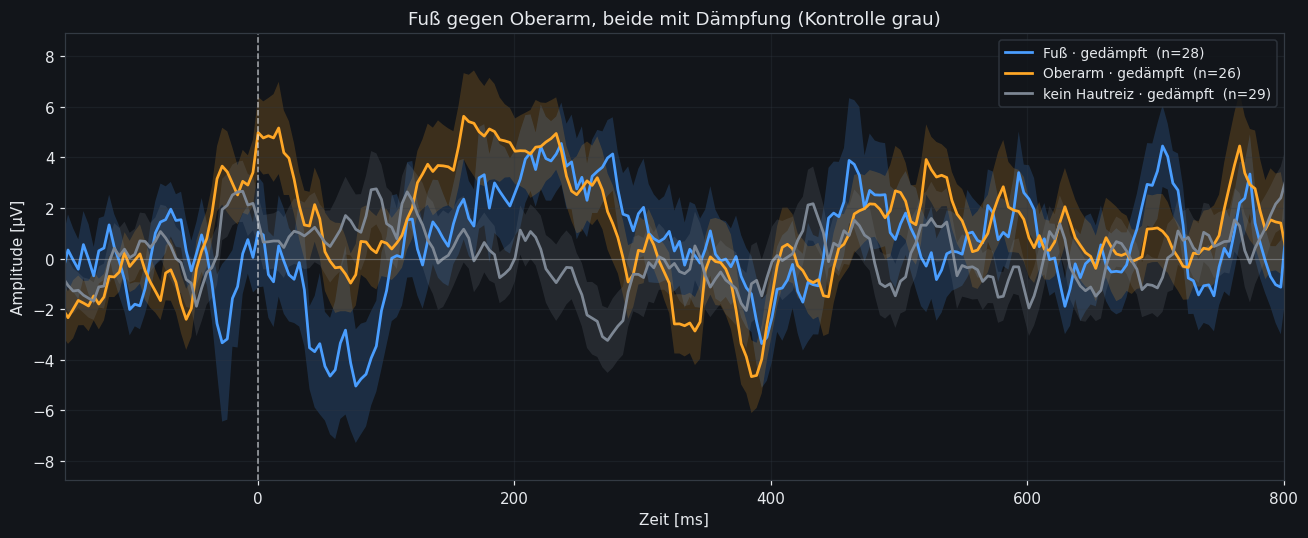

In [7]:
P2 = lambda x, tt: peak_latency(x, tt, (150, 400), "max")["latenz_ms"]
F, O = "Fuß · gedämpft", "Oberarm · gedämpft"
EF, EO = a13[F].epoch_traces(), a13[O].epoch_traces()

test_fo = cluster_permutation_test(EF, EO, t, window=(0, 800), n_perm=3000)
lat = bootstrap_difference(EO, EF, t, P2, n_boot=2000, n_perm=2000)
xk  = bootstrap_shift(EO, EF, t, window=(100, 500), max_lag_ms=150, n_boot=1500)

print(f"P2-Latenz Fuß − Oberarm : {lat['differenz']:+6.1f} ms "
      f"[{lat['lo']:+.0f}, {lat['hi']:+.0f}]  p={lat['p']:.3f}")
print(f"Kreuzkorrelation        : {xk['verschiebung_ms']:+6.1f} ms "
      f"[{xk['lo']:+.0f}, {xk['hi']:+.0f}]  r={xk['r']:.2f}")
print("\nCluster 0–800 ms:")
print(test_fo["cluster"].round(3).to_string(index=False)
      if len(test_fo["cluster"]) else "  keiner")

fig, ax = plt.subplots(figsize=(12, 5))
plot_compare({k: a13[k] for k in [F, O, B]}, "ROI", ax=ax, xlim=(-150, 800),
             clusters=test_fo, colors=farben([F, O, B]),
             title="Fuß gegen Oberarm, beide mit Dämpfung "
                   "(Kontrolle grau)")
fig.tight_layout()

### Warnung: der p-Wert oben trägt nicht

Die Gipfellatenz meldet hier einen Unterschied mit p < 0.05. Drei Gründe,
ihn **nicht** als Befund zu lesen:

1. **Die Maße widersprechen sich.** Die Gipfellatenz sagt rund +74 ms, die
   Kreuzkorrelation auf denselben Daten +9 ms. Letztere nutzt die ganze
   Kurvenform statt nur den Scheitel und ist das robustere Maß.
2. **Der Cluster-Test findet nichts** (bestes p > 0.6) — und der braucht
   kein vorher festgelegtes Fenster.
3. **Die Zahl hängt an der Trigger-Auswahl**, siehe nächste Zelle.

Dazu kommt die Rauschgrenze aus Abschnitt 5: zwei Aufnahmen **derselben**
Bedingung unterscheiden sich um rund 100 ms. Ein Effekt von 74 ms liegt
darunter.

Wenn ein Maß mit p < 0.05 meldet und zwei andere auf denselben Daten
nichts finden, ist die sparsamste Erklärung nicht, dass das eine Maß
empfindlicher war.

In [8]:
P2 = lambda x, tt: peak_latency(x, tt, (150, 400), "max")["latenz_ms"]

zeilen = []
for lab, kw in [("last=40", dict(last=40)),
                ("drop_first=10", dict(drop_first=10)),
                ("drop_first=10, last=29", dict(drop_first=10, last=29)),
                ("drop_first=10, last=25", dict(drop_first=10, last=25))]:
    E = {}
    for k in (F, O):
        s = load_session(AUG13[k])
        eeg = OfflineFilter(fs=s.fs).highpass(1.0).notch(50.0)(s.raw)
        r = replay(eeg, s.trigger_idx, fs=s.fs, ch_labels=s.ch_labels,
                   pre_ms=200, post_ms=2000, mad_k=3.5, threshold=None,
                   with_tfr=False, **kw)
        E[k] = r.epochs[:, :, [r.ch(c) for c in ROI]].mean(2)
    d = bootstrap_difference(E[O], E[F], t, P2, n_boot=2000, n_perm=2000)
    x = bootstrap_shift(E[O], E[F], t, window=(100, 500), max_lag_ms=150,
                        n_boot=1500)
    zeilen.append({"Auswahl": lab, "n Fuß/Oberarm": f"{len(E[F])}/{len(E[O])}",
                   "P2-Latenz Δ": f"{d['differenz']:+.0f} ms",
                   "p": round(d["p"], 3),
                   "Kreuzkorr. Δ": f"{x['verschiebung_ms']:+.0f} ms"})
pd.DataFrame(zeilen)

,Auswahl,n Fuß/Oberarm,P2-Latenz Δ,p,Kreuzkorr. Δ
0,last=40,39/40,+16 ms,0.788,+15 ms
1,drop_first=10,36/34,+45 ms,0.115,+33 ms
2,"drop_first=10, last=29",28/26,+74 ms,0.043,+9 ms
3,"drop_first=10, last=25",24/23,+75 ms,0.056,+10 ms


### Die Gegenprobe: was kann das Maß überhaupt auflösen?

Dieselbe Bedingung in zwei Hälften geteilt. Da liegt per Konstruktion
**kein** Unterschied vor — was hier herauskommt, ist die Auflösungsgrenze.
Ein Bedingungsunterschied, der kleiner ist, lässt sich nicht deuten, egal
wie hübsch sein Vertrauensbereich aussieht.

In [9]:
zeilen = []
for name, v in a13.items():
    ep = v.epoch_traces(); h = len(ep) // 2
    d = bootstrap_difference(ep[:h], ep[h:], t, P2, n_boot=1500, n_perm=1500)
    x = bootstrap_shift(ep[:h], ep[h:], t, window=(100, 500),
                        max_lag_ms=150, n_boot=1000)
    zeilen.append({"Bedingung": name, "n je Hälfte": h,
                   "P2-Latenz Δ": f"{d['differenz']:+.0f} ms [{d['lo']:+.0f}, {d['hi']:+.0f}]",
                   "Kreuzkorr. Δ": f"{x['verschiebung_ms']:+.0f} ms [{x['lo']:+.0f}, {x['hi']:+.0f}]"})
pd.DataFrame(zeilen)

,Bedingung,n je Hälfte,P2-Latenz Δ,Kreuzkorr. Δ
0,Fuß · gedämpft,14,"-16 ms [-102, +92]","-33 ms [-103, +40]"
1,Oberarm · gedämpft,13,"+17 ms [-95, +170]","-48 ms [-69, +42]"
2,kein Hautreiz · gedämpft,14,"+54 ms [-184, +192]","+124 ms [-144, +141]"
3,kein Hautreiz · ungedämpft,14,"+112 ms [-154, +139]","-9 ms [-105, +148]"


## 5 · Frage 3 — Der fokussierende Applikator

Die aussagekräftigste Auswertung des Datensatzes, weil der normale Kopf
**zweimal** gemessen wurde: das liefert die Nullverteilung, gegen die der
Applikatoreffekt antreten muss.

Wichtig ist die Wahl des Maßes. Gipfelamplituden taugen hier schlecht — die
Suche nach dem Größten in einem Fenster findet auch im reinen Rauschen
etwas, und zwar umso mehr, je weniger Epochen gemittelt wurden. Deshalb:

* **mittlere Amplitude** und **rauschbereinigte Leistung** — unverzerrt
* **Split-half-Reliabilität** und **Einzeltrial-Konsistenz** — hängen von n
  ab und werden deshalb alle auf dieselbe Epochenzahl heruntergezogen

Für einen Applikator ist die Reliabilität das direktere Gütemaß: einer, der
zuverlässiger reizt, erzeugt von Versuch zu Versuch dieselbe Antwort —
unabhängig davon, wie groß sie ist.

In [10]:
L  = "Wade · Linse"
K1 = "Wade · normaler Kopf (1)"
K2 = "Wade · normaler Kopf (2)"
W_REL, N_REL = (100, 500), 21          # kleinste Bedingung

EL, EK1, EK2 = (s09[L].epoch_traces(), s09[K1].epoch_traces(),
                s09[K2].epoch_traces())
EK = np.vstack([EK1, EK2])

# Kurvenform und Amplitude
test_ap = cluster_permutation_test(EL, EK, t, window=(0, 800), n_perm=3000)
for nm, fn in [("mittlere Amplitude N1 (0–150 ms)",
                lambda x, tt: x[(tt >= 0) & (tt <= 150)].mean()),
               ("mittlere Amplitude P2 (150–450 ms)",
                lambda x, tt: x[(tt >= 150) & (tt <= 450)].mean())]:
    eff = bootstrap_difference(EK, EL, t, fn, n_boot=2000, n_perm=2000)
    nul = bootstrap_difference(EK1, EK2, t, fn, n_boot=2000, n_perm=2000)
    print(f"{nm:36s} EFFEKT {eff['differenz']:+6.2f} µV p={eff['p']:.3f}"
          f"  |  NULL {nul['differenz']:+6.2f} µV p={nul['p']:.3f}")
print(f"\nCluster-Test Linse vs Kopf: bestes p = {test_ap['cluster']['p'].min():.2f}"
      if len(test_ap["cluster"]) else "\nCluster-Test: gar kein Cluster")

mittlere Amplitude N1 (0–150 ms)     EFFEKT  +0.23 µV p=0.919  |  NULL  -1.12 µV p=0.681
mittlere Amplitude P2 (150–450 ms)   EFFEKT  -0.14 µV p=0.931  |  NULL  -3.37 µV p=0.073

Cluster-Test Linse vs Kopf: bestes p = 0.75


In [11]:
def guete(ep, n_zieh=200, seed=0):
    """Reliabilität und Einzeltrial-Konsistenz bei angeglichenem n,
    mit Streuung über wiederholtes Herunterziehen."""
    rng = np.random.default_rng(seed)
    rs, cs = [], []
    for k in range(n_zieh):
        sub = ep[np.sort(rng.choice(len(ep), min(N_REL, len(ep)), replace=False))]
        rs.append(split_half_reliability(sub, t, W_REL, n_rep=300, seed=k))
        cs.append(single_trial_consistency(sub, t, W_REL)["r_mittel"])
    return np.array(rs), np.array(cs)

zeilen = []
for k, name in enumerate([L, K1, K2]):
    ep = s09[name].epoch_traces()
    rs, cs = guete(ep, seed=k)
    zeilen.append({
        "Bedingung": name, "n gesamt": len(ep), "n verglichen": N_REL,
        "Reliabilität": f"{np.median(rs):+.2f} [{np.percentile(rs, 2.5):+.2f}, {np.percentile(rs, 97.5):+.2f}]",
        "Einzeltrial r": f"{np.median(cs):+.3f}",
        "Basisrauschen µV": round(float(ep[:, (t >= -200) & (t <= 0)].std()), 1)})
pd.DataFrame(zeilen)

,Bedingung,n gesamt,n verglichen,Reliabilität,Einzeltrial r,Basisrauschen µV
0,Wade · Linse,25,21,"+0.53 [+0.40, +0.64]",+0.172,13.3
1,Wade · normaler Kopf (1),29,21,"-0.09 [-0.71, +0.44]",+0.013,9.0
2,Wade · normaler Kopf (2),21,21,"-0.00 [-0.10, +0.08]",-0.016,15.7


Die Linse hat **mehr** Basisrauschen als Kopf (1) und trotzdem die höhere
Reliabilität — eine sauberere Aufnahme erklärt den Unterschied also nicht.

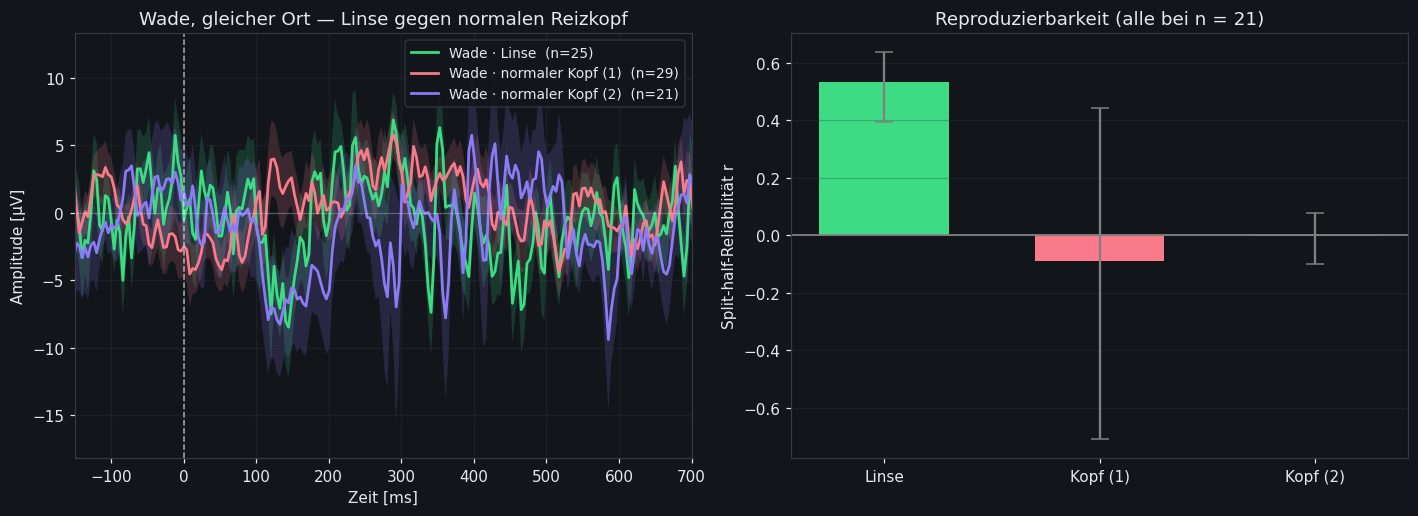

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
plot_compare({k: s09[k] for k in [L, K1, K2]}, "ROI", ax=ax[0],
             xlim=(-150, 700), clusters=test_ap, colors=farben([L, K1, K2]),
             title="Wade, gleicher Ort — Linse gegen normalen Reizkopf")

namen = ["Linse", "Kopf (1)", "Kopf (2)"]
werte = [guete(s09[n].epoch_traces(), seed=k) for k, n in enumerate([L, K1, K2])]
med = [np.median(w[0]) for w in werte]
lo  = [np.percentile(w[0], 2.5) for w in werte]
hi  = [np.percentile(w[0], 97.5) for w in werte]
ax[1].bar(range(3), med, 0.6, color=[FARBEN[L], FARBEN[K1], FARBEN[K2]],
          yerr=[np.array(med) - lo, np.array(hi) - med], capsize=6, ecolor="gray")
ax[1].axhline(0, color="gray", lw=1.2)
ax[1].set_xticks(range(3)); ax[1].set_xticklabels(namen)
ax[1].set_ylabel("Split-half-Reliabilität r")
ax[1].set_title(f"Reproduzierbarkeit (alle bei n = {N_REL})")
ax[1].grid(alpha=0.3, axis="y")
fig.tight_layout()

### Ist es der Applikator oder die Uhrzeit?

Die Linse wurde zuerst gemessen — Reihenfolge und Applikator sind
verwechselbar. Fiele die Reliabilität einfach über die Sitzung ab, müsste
die früheste Aufnahme die beste sein.

In [13]:
zeilen = []
for name in SEP9:
    s = load_session(SEP9[name])
    ep = s09[name].epoch_traces()
    rs, _ = guete(ep, n_zieh=150)
    h = len(ep) // 2
    zeilen.append({
        "Zeit": s.meta.get("gestartet", "")[11:16], "Bedingung": name,
        "n": len(ep),
        "Reliabilität (n=21)": f"{np.median(rs):+.2f} [{np.percentile(rs, 2.5):+.2f}, {np.percentile(rs, 97.5):+.2f}]",
        "Hälfte 1 / 2": (f"{split_half_reliability(ep[:h], t, W_REL, n_rep=300):+.2f} / "
                         f"{split_half_reliability(ep[h:], t, W_REL, n_rep=300):+.2f}")})
pd.DataFrame(zeilen).sort_values("Zeit")

,Zeit,Bedingung,n,Reliabilität (n=21),Hälfte 1 / 2
0,16:37,kein Hautreiz · gedämpft,49,"+0.03 [-1.38, +0.62]",-0.16 / -0.33
1,16:45,Oberschenkel · Linse,45,"+0.74 [+0.58, +0.86]",+0.85 / +0.86
2,16:52,Wade · Linse,25,"+0.53 [+0.40, +0.63]",+0.49 / +0.41
3,17:00,Wade · normaler Kopf (1),29,"-0.08 [-0.86, +0.41]",+0.41 / -0.34
4,17:11,Wade · normaler Kopf (2),21,"-0.01 [-0.10, +0.08]",+0.28 / +0.24


## 6 · Frage 4 — Oberschenkel gegen Wade

Gleicher Reizkopf (Linse), unterschiedliche Entfernung zum Gehirn. Der Weg
ist rund 40–55 cm länger; bei nozizeptiven Aδ-Fasern (10–15 m/s) wären das
27–55 ms, bei schnellen Aβ-Fasern (~50 m/s) nur etwa 9 ms.

P2-Latenz Wade − Oberschenkel :  +44.5 ms [-72, +137]  p=0.599
Kreuzkorrelation              :   -4.9 ms [-37, +47]
NULL (Kopf 1 gegen Kopf 2)    : +107.9 ms — so groß ist der Unterschied ZWISCHEN WIEDERHOLUNGEN derselben Bedingung


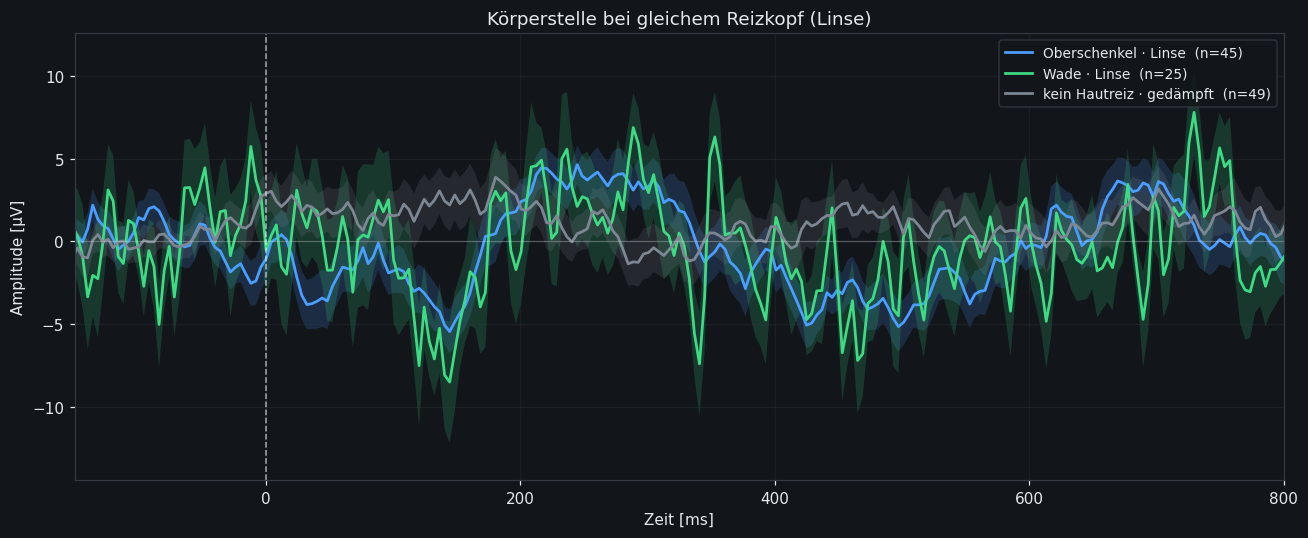

In [14]:
OS, WA = "Oberschenkel · Linse", "Wade · Linse"
EOS, EWA = s09[OS].epoch_traces(), s09[WA].epoch_traces()

test_os = cluster_permutation_test(EWA, EOS, t, window=(0, 800), n_perm=3000)
lat = bootstrap_difference(EOS, EWA, t, P2, n_boot=2000, n_perm=2000)
xk  = bootstrap_shift(EOS, EWA, t, window=(100, 600), max_lag_ms=150, n_boot=1500)
nul = bootstrap_difference(EK1, EK2, t, P2, n_boot=2000, n_perm=2000)

print(f"P2-Latenz Wade − Oberschenkel : {lat['differenz']:+6.1f} ms "
      f"[{lat['lo']:+.0f}, {lat['hi']:+.0f}]  p={lat['p']:.3f}")
print(f"Kreuzkorrelation              : {xk['verschiebung_ms']:+6.1f} ms "
      f"[{xk['lo']:+.0f}, {xk['hi']:+.0f}]")
print(f"NULL (Kopf 1 gegen Kopf 2)    : {nul['differenz']:+6.1f} ms "
      f"— so groß ist der Unterschied ZWISCHEN WIEDERHOLUNGEN derselben Bedingung")

fig, ax = plt.subplots(figsize=(12, 5))
plot_compare({k: s09[k] for k in [OS, WA, "kein Hautreiz · gedämpft"]}, "ROI",
             ax=ax, xlim=(-150, 800), clusters=test_os,
             colors=farben([OS, WA, "kein Hautreiz · gedämpft"]),
             title="Körperstelle bei gleichem Reizkopf (Linse)")
fig.tight_layout()

## 7 · Was diese Zahlen tragen — und was nicht

* Eine Person, eine Sitzung je Reihe, 21–29 Epochen je Bedingung. Das
  erlaubt Aussagen über **diese Messungen**, nicht über Menschen im
  Allgemeinen.
* Die Bedingungen wurden **nacheinander** aufgenommen, nicht verschachtelt.
  Alles, was sich über die Stunde ändert — Elektrodenimpedanz, Wachheit,
  Gewöhnung — liegt deckungsgleich auf dem Bedingungsunterschied. Die
  Wiederholungsmessung in Abschnitt 5 zeigt, dass das keine Kleinigkeit
  ist: zwei Aufnahmen derselben Bedingung unterscheiden sich in der
  P2-Latenz um rund 100 ms.
* Beim Applikator sind Reihenfolge und Bedingung vollständig verwechselbar
  (Linse, Linse, Kopf, Kopf). Die Zeitkontrolle macht die Zeiterklärung
  unwahrscheinlich, sie widerlegt sie nicht.

**Der größte Hebel für die nächste Messung:** Bedingungen **innerhalb einer
Aufnahme abwechseln**, etwa blockweise zu je zehn Reizen. Dann trägt jede
Bedingung dieselbe Drift, und der Unterschied bleibt als Unterschied
stehen. Das bringt mehr als jede Erhöhung der Epochenzahl.